# **1. Perkenalan Dataset**

## Dry Bean Dataset

**Sumber:** [Kaggle - Dry Bean Dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset)  
**Referensi asli:** UCI ML Repository (Koklu & Ozkan, 2020)

Dataset ini berisi hasil pengukuran morfologi dari 13.611 biji kacang kering yang difoto menggunakan sistem visi komputer. Setiap biji diklasifikasikan ke dalam **7 kelas varietas kacang**:
- Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira

**Fitur (16 fitur numerik):**
| Fitur | Keterangan |
|---|---|
| Area | Luas area biji (pixel) |
| Perimeter | Keliling biji |
| MajorAxisLength | Panjang sumbu mayor |
| MinorAxisLength | Panjang sumbu minor |
| AspectRation | Rasio aspek |
| Eccentricity | Eksentrisitas |
| ConvexArea | Luas convex hull |
| EquivDiameter | Diameter ekuivalen |
| Extent | Rasio area terhadap bounding box |
| Solidity | Kepadatan |
| roundness | Kebulatan |
| Compactness | Kompaksi |
| ShapeFactor1-4 | Faktor bentuk 1-4 |

**Target:** `Class` — 7 kelas varietas kacang kering

**Task:** Multiclass Classification

# **2. Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.2.3
NumPy version: 2.3.5


# **3. Memuat Dataset**

In [5]:
# Install openpyxl untuk baca file Excel (dataset asli .xlsx)
!pip install openpyxl -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\asusa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# Load dataset
# Download dari: https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset
# Letakkan file Dry_Bean_Dataset.xlsx di folder yang sama dengan notebook ini

df = pd.read_excel('../Dry_Bean_Dataset_raw/Dry_Bean_Dataset.xlsx')

print('=== INFO DATASET ===')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print()
print('=== 5 BARIS PERTAMA ===')
df.head()

=== INFO DATASET ===
Shape: (13611, 17)
Jumlah baris: 13611
Jumlah kolom: 17

=== 5 BARIS PERTAMA ===


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [7]:
# Cek tipe data dan info umum
print('=== INFO KOLOM ===')
df.info()
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


# **4. Exploratory Data Analysis (EDA)**

=== DISTRIBUSI KELAS TARGET ===
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64



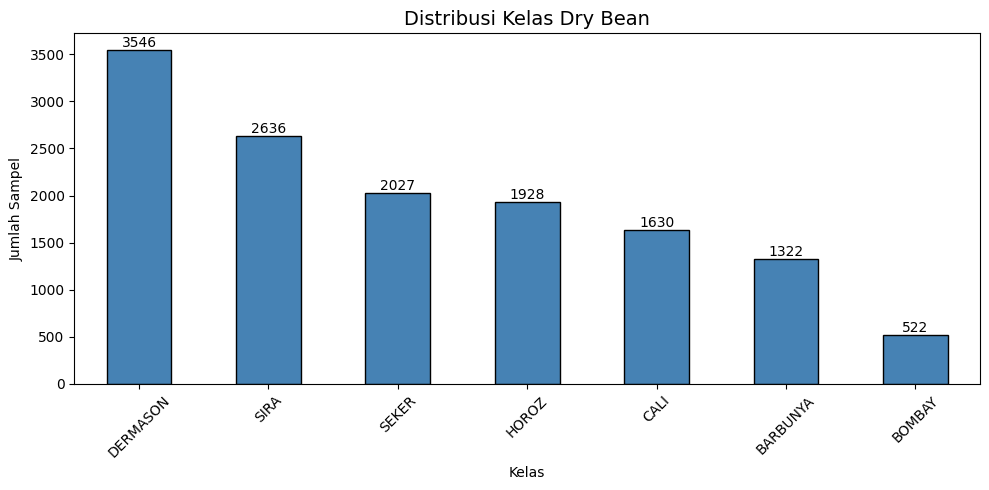

In [8]:
# ===== 4.1 Distribusi Target =====
print('=== DISTRIBUSI KELAS TARGET ===')
class_dist = df['Class'].value_counts()
print(class_dist)
print()

plt.figure(figsize=(10, 5))
ax = class_dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kelas Dry Bean', fontsize=14)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# ===== 4.2 Missing Values =====
print('=== CEK MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {missing.sum()}')

=== CEK MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


In [10]:
# ===== 4.3 Duplikasi =====
print('=== CEK DUPLIKASI ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== CEK DUPLIKASI ===
Jumlah baris duplikat: 68


Fitur numerik (16): ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


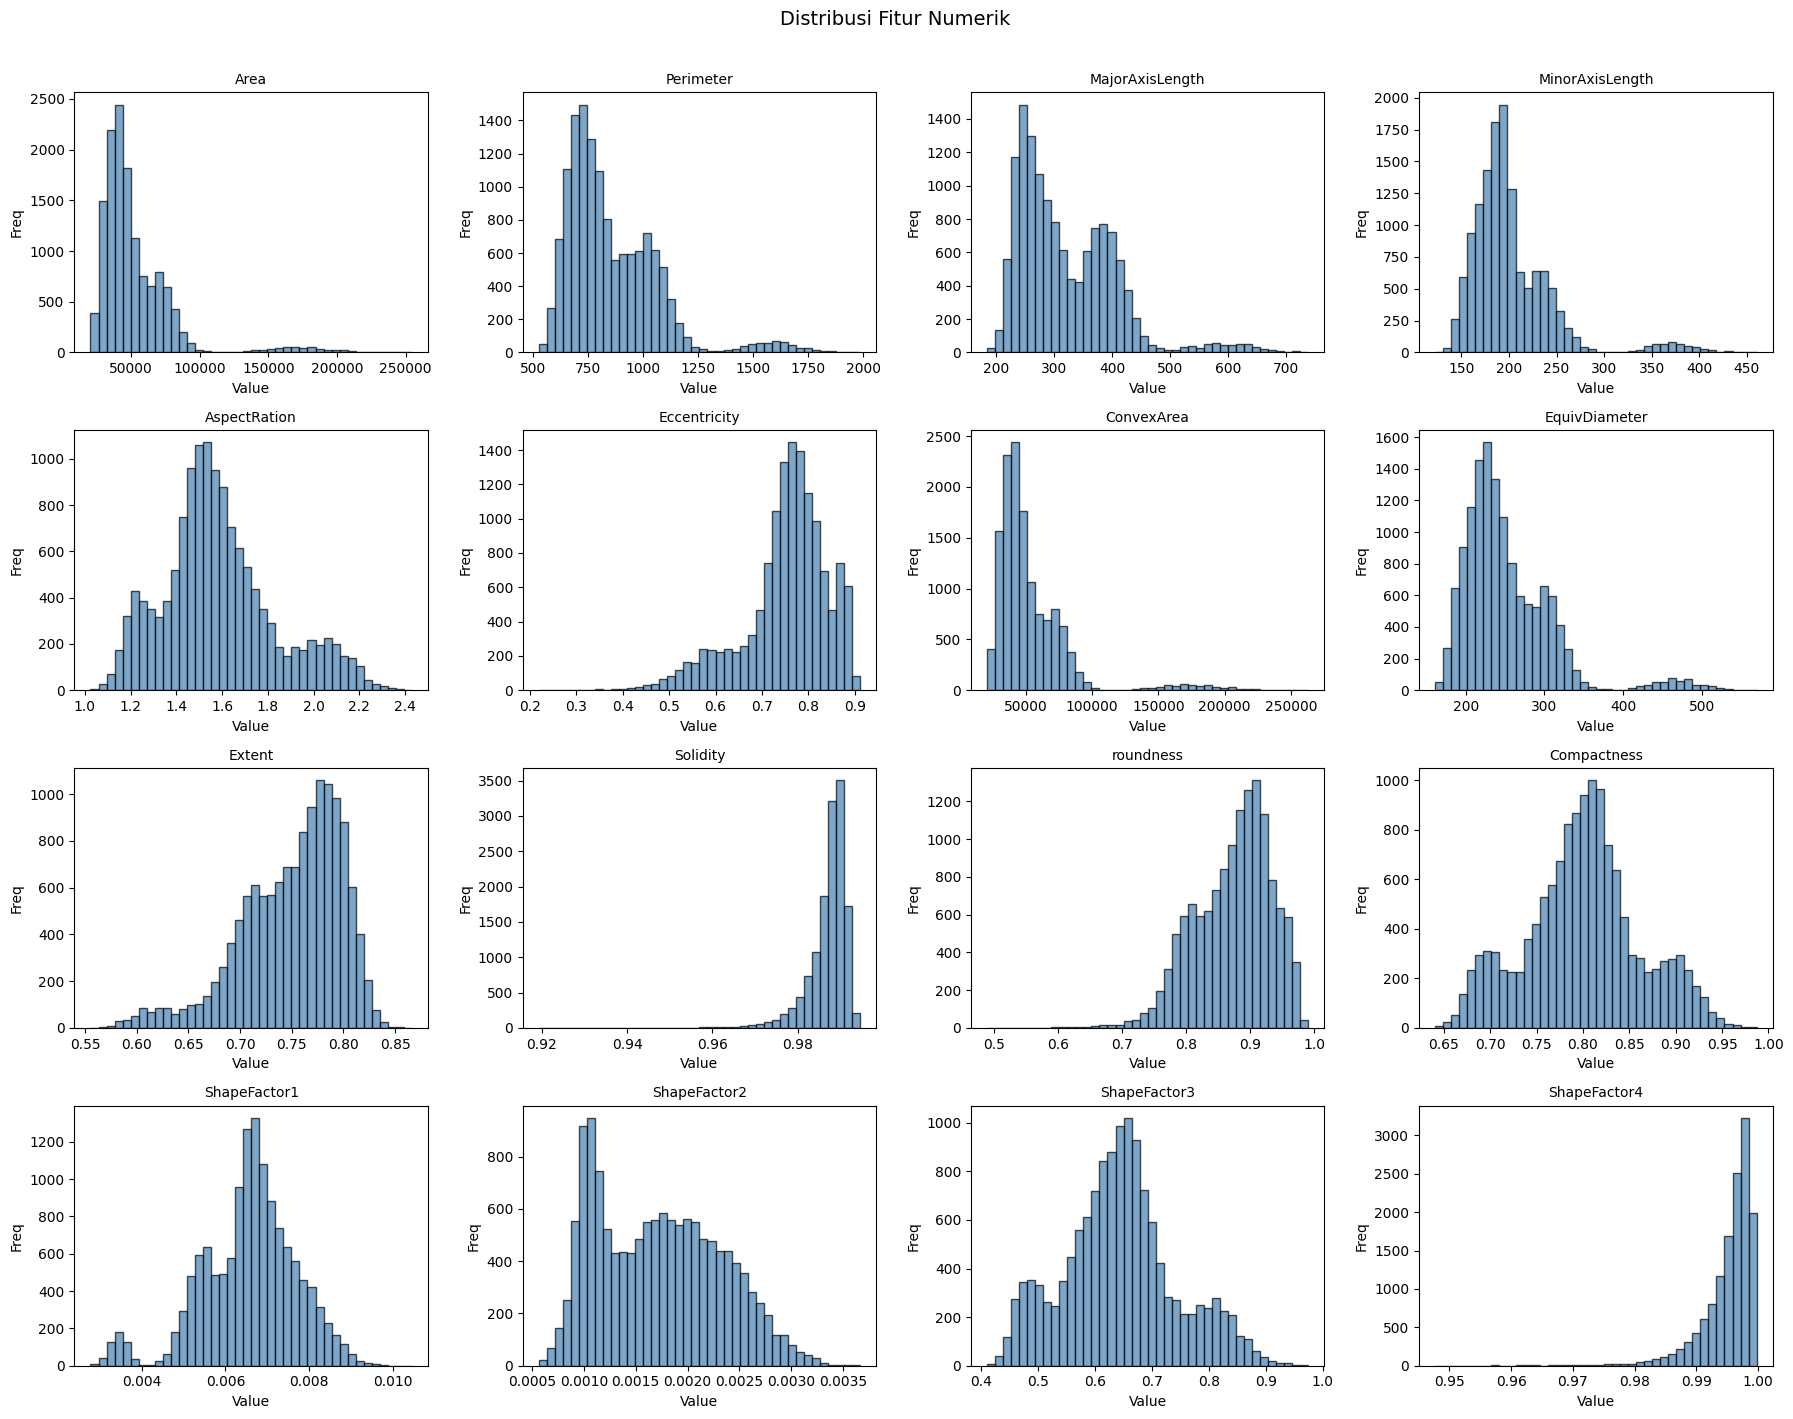

In [11]:
# ===== 4.4 Distribusi Fitur Numerik =====
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Fitur numerik ({len(numeric_cols)}): {numeric_cols}')

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Freq')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

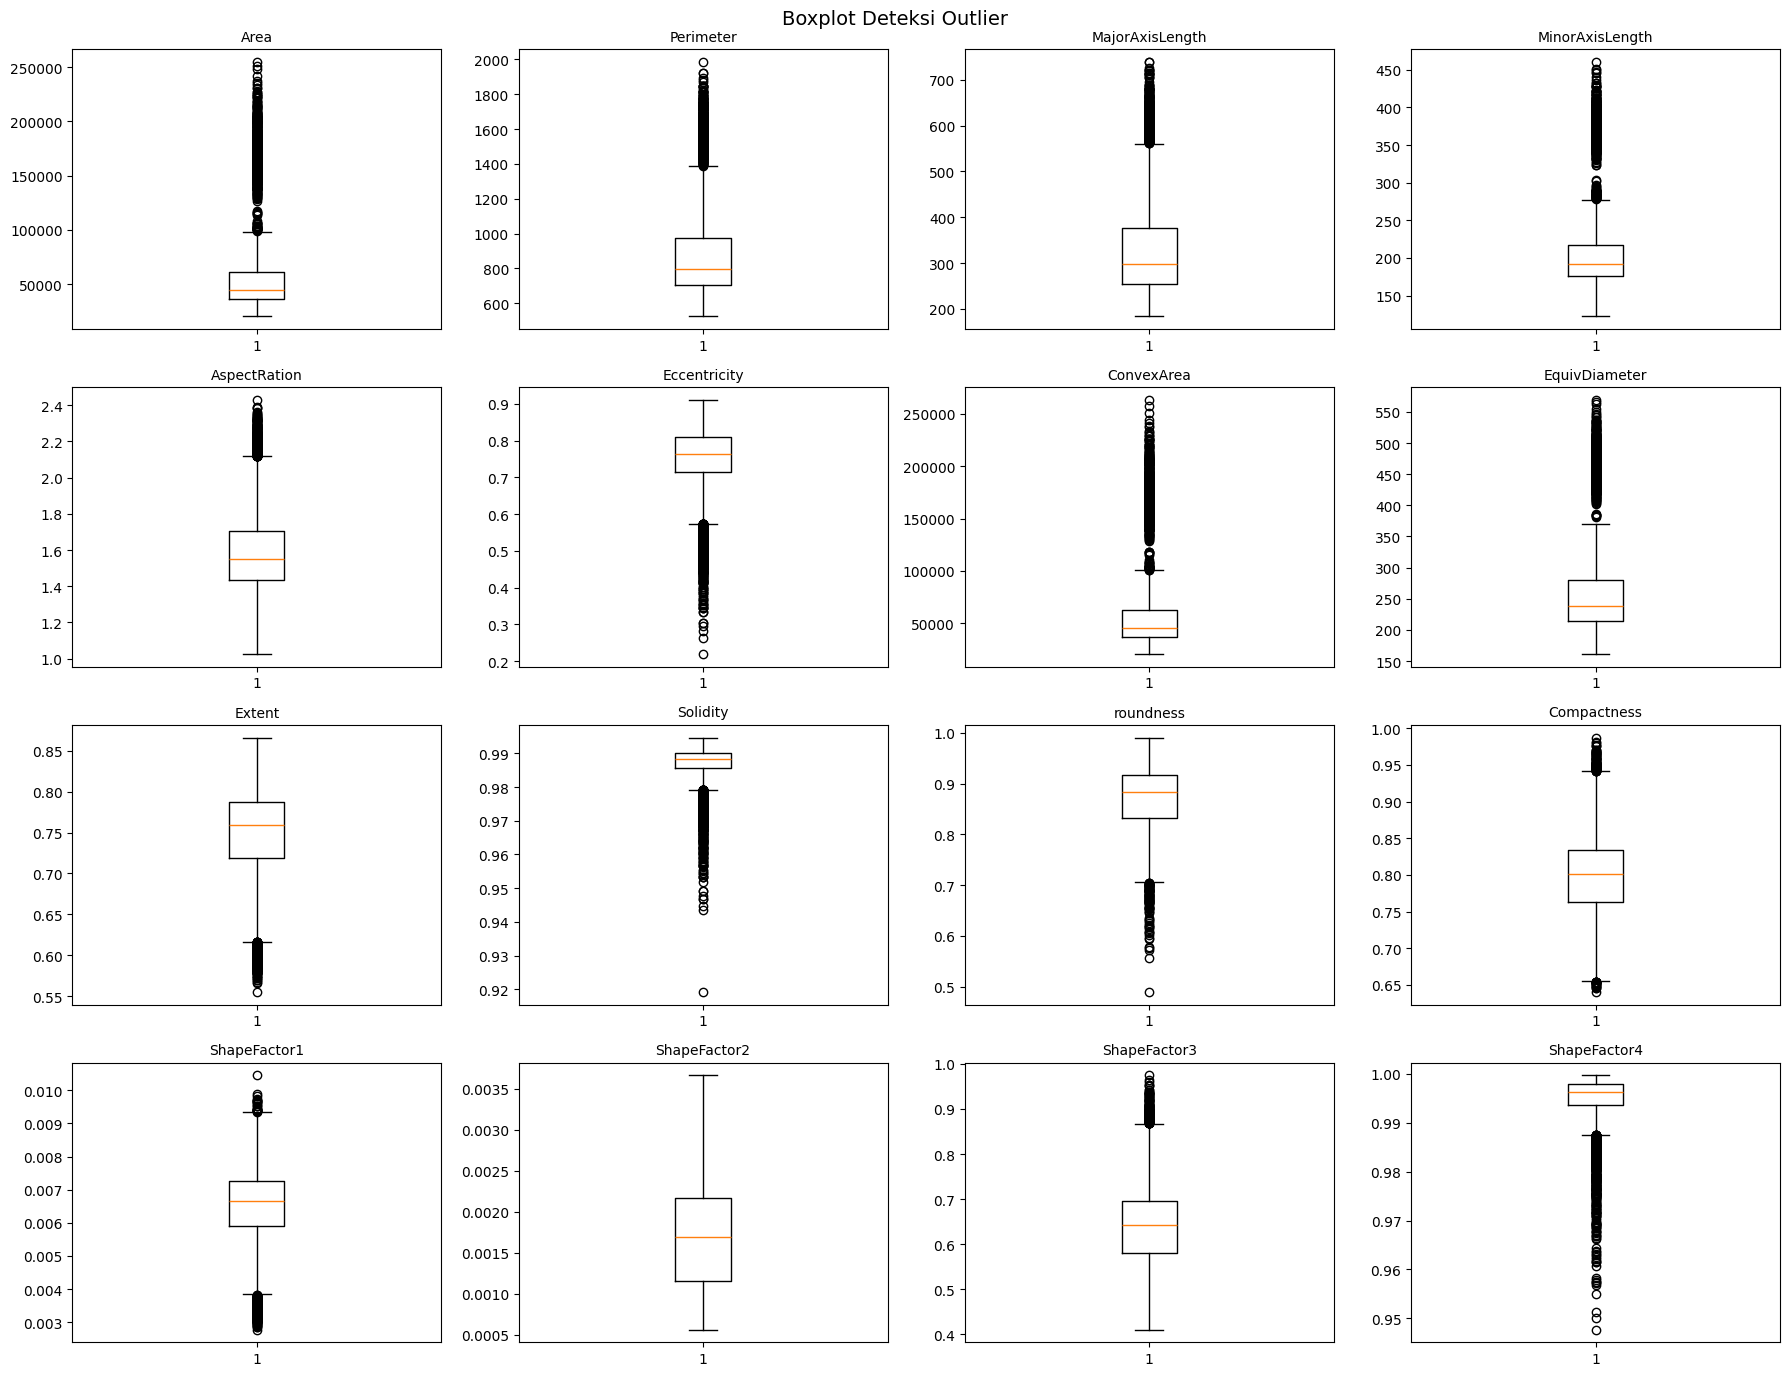

=== JUMLAH OUTLIER PER FITUR (IQR Method) ===
Area: 551 outlier (4.05%)
Perimeter: 500 outlier (3.67%)
MajorAxisLength: 379 outlier (2.78%)
MinorAxisLength: 569 outlier (4.18%)
AspectRation: 473 outlier (3.48%)
Eccentricity: 843 outlier (6.19%)
ConvexArea: 550 outlier (4.04%)
EquivDiameter: 526 outlier (3.86%)
Extent: 275 outlier (2.02%)
Solidity: 778 outlier (5.72%)
roundness: 91 outlier (0.67%)
Compactness: 109 outlier (0.80%)
ShapeFactor1: 533 outlier (3.92%)
ShapeFactor2: 0 outlier (0.00%)
ShapeFactor3: 195 outlier (1.43%)
ShapeFactor4: 767 outlier (5.64%)


In [12]:
# ===== 4.5 Deteksi Outlier dengan Boxplot =====
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot Deteksi Outlier', fontsize=14)
plt.tight_layout()
plt.show()

# Hitung jumlah outlier per kolom (IQR method)
print('=== JUMLAH OUTLIER PER FITUR (IQR Method) ===')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {outliers} outlier ({outliers/len(df)*100:.2f}%)')

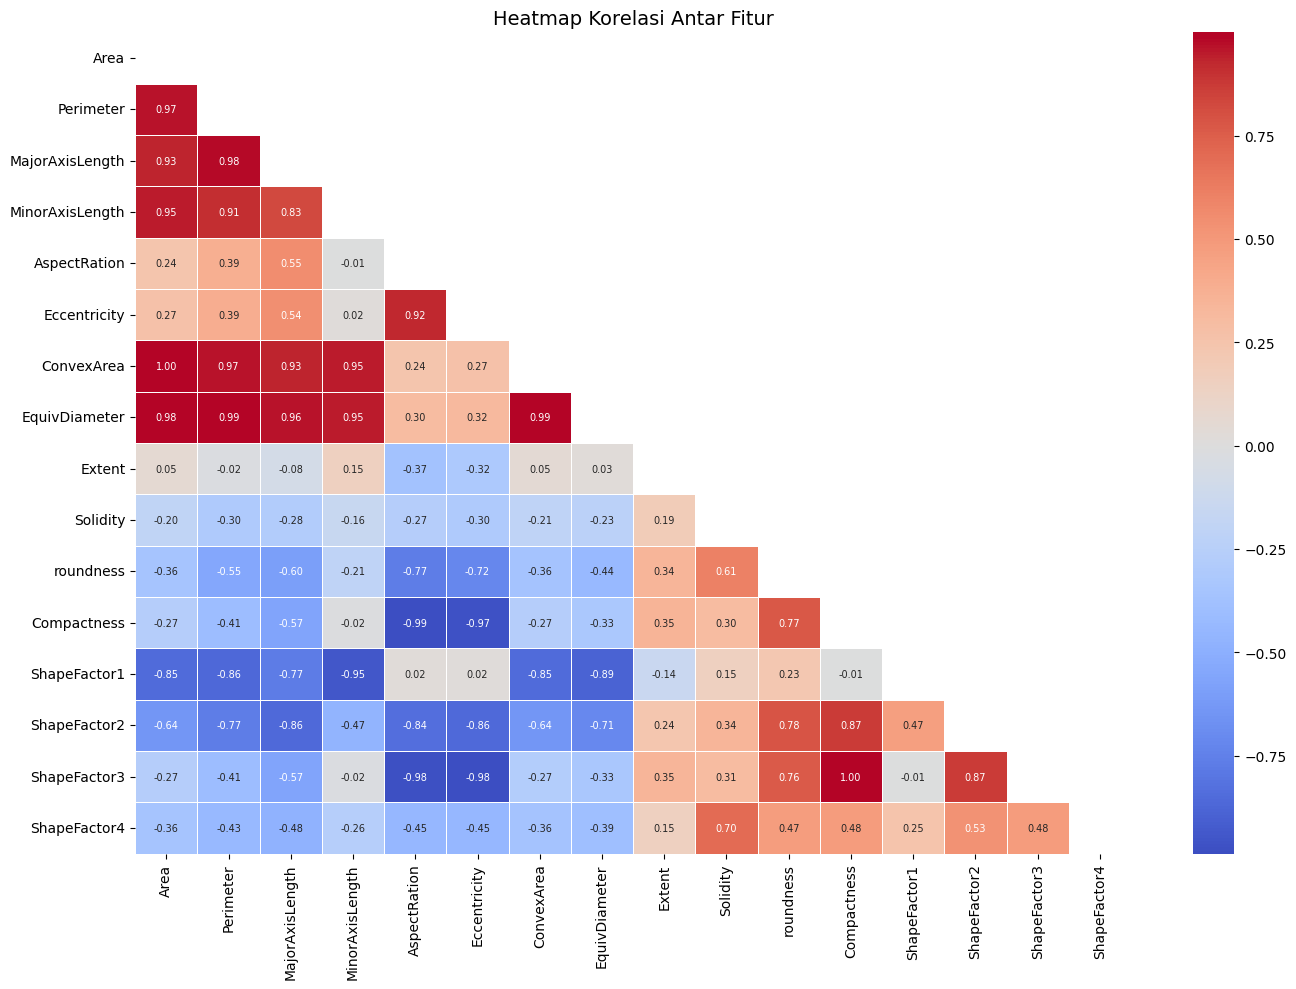


Pasangan fitur dengan korelasi > 0.95:
  Perimeter & Area: 0.967
  MajorAxisLength & Perimeter: 0.977
  MinorAxisLength & Area: 0.952
  ConvexArea & Area: 1.000
  ConvexArea & Perimeter: 0.968
  ConvexArea & MinorAxisLength: 0.951
  EquivDiameter & Area: 0.985
  EquivDiameter & Perimeter: 0.991
  EquivDiameter & MajorAxisLength: 0.962
  EquivDiameter & ConvexArea: 0.985
  Compactness & AspectRation: -0.988
  Compactness & Eccentricity: -0.970
  ShapeFactor3 & AspectRation: -0.979
  ShapeFactor3 & Eccentricity: -0.981
  ShapeFactor3 & Compactness: 0.999


In [13]:
# ===== 4.6 Heatmap Korelasi =====
plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

# Cek fitur dengan korelasi tinggi (>0.95)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                               corr_matrix.iloc[i, j]))
print(f'\nPasangan fitur dengan korelasi > 0.95:')
for c in high_corr:
    print(f'  {c[0]} & {c[1]}: {c[2]:.3f}')

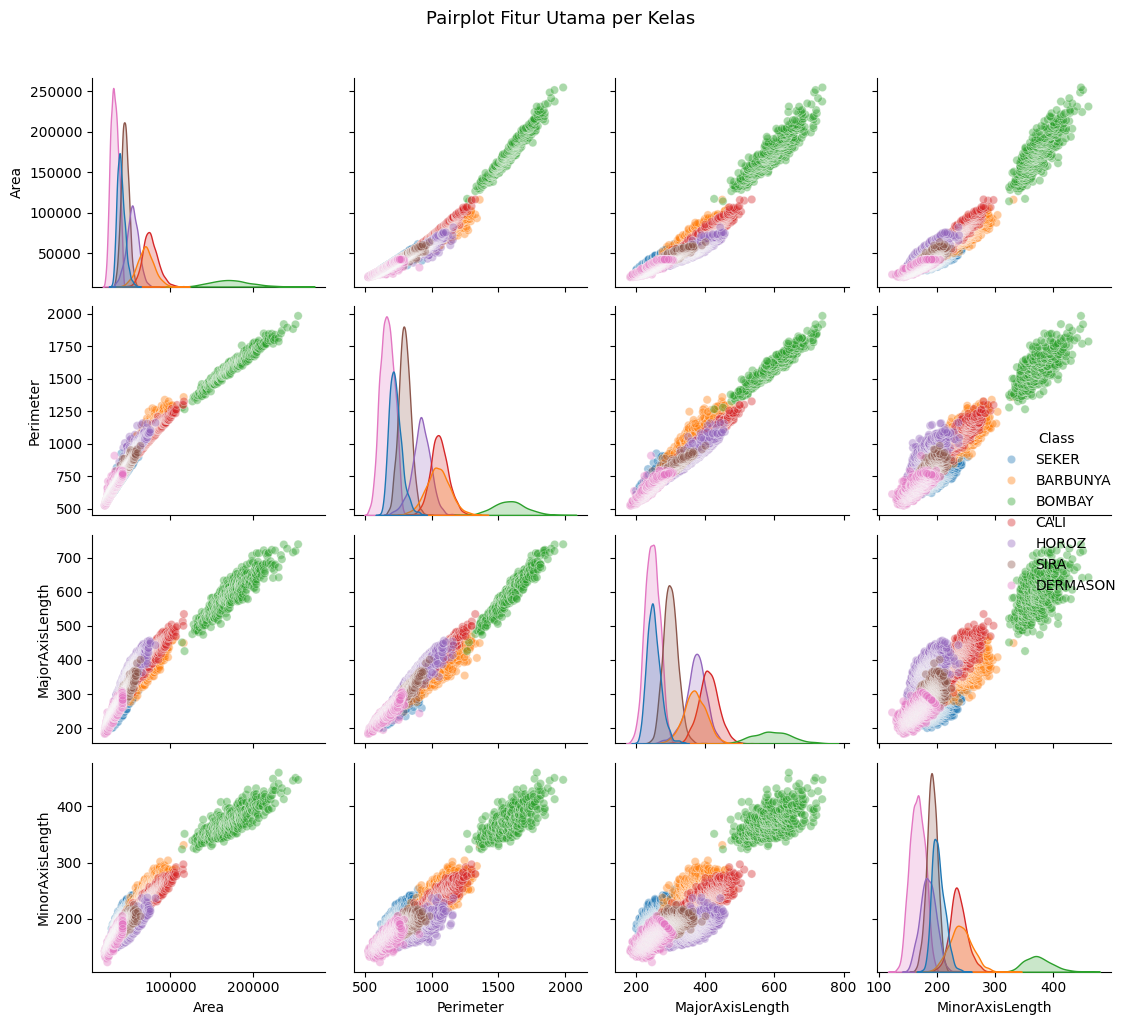

In [14]:
# ===== 4.7 Pairplot sample fitur utama =====
sample_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Class']
sns.pairplot(df[sample_features], hue='Class', plot_kws={'alpha': 0.4}, height=2.5)
plt.suptitle('Pairplot Fitur Utama per Kelas', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [15]:
# ===== 5.1 Hapus Missing Values =====
print(f'Shape sebelum hapus missing: {df.shape}')
df_clean = df.dropna()
print(f'Shape setelah hapus missing: {df_clean.shape}')
print(f'Baris dihapus: {df.shape[0] - df_clean.shape[0]}')

Shape sebelum hapus missing: (13611, 17)
Shape setelah hapus missing: (13611, 17)
Baris dihapus: 0


In [16]:
# ===== 5.2 Hapus Duplikasi =====
print(f'Shape sebelum hapus duplikat: {df_clean.shape}')
df_clean = df_clean.drop_duplicates()
print(f'Shape setelah hapus duplikat: {df_clean.shape}')

Shape sebelum hapus duplikat: (13611, 17)
Shape setelah hapus duplikat: (13543, 17)


In [17]:
# ===== 5.3 Penanganan Outlier (IQR Clipping) =====
# Gunakan clipping agar data tidak hilang terlalu banyak
df_no_outlier = df_clean.copy()

for col in numeric_cols:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outlier[col] = df_no_outlier[col].clip(lower=lower, upper=upper)

print('Outlier berhasil ditangani dengan IQR Clipping')
print(f'Shape data: {df_no_outlier.shape}')

Outlier berhasil ditangani dengan IQR Clipping
Shape data: (13543, 17)


In [18]:
# ===== 5.4 Label Encoding pada Target =====
le = LabelEncoder()
df_no_outlier['Class_encoded'] = le.fit_transform(df_no_outlier['Class'])

print('=== Mapping Label Encoding ===')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

=== Mapping Label Encoding ===
  BARBUNYA -> 0
  BOMBAY -> 1
  CALI -> 2
  DERMASON -> 3
  HOROZ -> 4
  SEKER -> 5
  SIRA -> 6


In [19]:
# ===== 5.5 Pisah Fitur dan Target =====
X = df_no_outlier[numeric_cols]
y = df_no_outlier['Class_encoded']

print(f'Shape X (fitur): {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'\nDistribusi kelas setelah preprocessing:')
print(y.value_counts())

Shape X (fitur): (13543, 16)
Shape y (target): (13543,)

Distribusi kelas setelah preprocessing:
Class_encoded
3    3546
6    2636
5    2027
4    1860
2    1630
0    1322
1     522
Name: count, dtype: int64


In [20]:
# ===== 5.6 Normalisasi Fitur (StandardScaler) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

print('Normalisasi selesai. Statistik setelah scaling:')
print(X_scaled.describe().loc[['mean', 'std']].round(4))

Normalisasi selesai. Statistik setelah scaling:
      Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
mean   0.0       -0.0              0.0             -0.0          -0.0   
std    1.0        1.0              1.0              1.0           1.0   

      Eccentricity  ConvexArea  EquivDiameter  Extent  Solidity  roundness  \
mean          -0.0         0.0            0.0     0.0      -0.0        0.0   
std            1.0         1.0            1.0     1.0       1.0        1.0   

      Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
mean          0.0          -0.0           0.0          -0.0          -0.0  
std           1.0           1.0           1.0           1.0           1.0  


In [21]:
# ===== 5.7 Train-Test Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape : {y_test.shape}')
print(f'\nRasio train: {len(X_train)/len(X_scaled)*100:.1f}%')
print(f'Rasio test : {len(X_test)/len(X_scaled)*100:.1f}%')

X_train shape: (10834, 16)
X_test shape : (2709, 16)
y_train shape: (10834,)
y_test shape : (2709,)

Rasio train: 80.0%
Rasio test : 20.0%


In [22]:
# ===== 5.8 Simpan Data yang Sudah Dipreprocessing =====
os.makedirs('Dry_Bean_Dataset_preprocessing', exist_ok=True)

# Gabung X_scaled dengan y untuk disimpan
df_preprocessed = X_scaled.copy()
df_preprocessed['Class'] = y.values

train_df = X_train.copy()
train_df['Class'] = y_train.values

test_df = X_test.copy()
test_df['Class'] = y_test.values

df_preprocessed.to_csv('Dry_Bean_Dataset_preprocessing/dry_bean_preprocessed.csv', index=False)
train_df.to_csv('Dry_Bean_Dataset_preprocessing/dry_bean_train.csv', index=False)
test_df.to_csv('Dry_Bean_Dataset_preprocessing/dry_bean_test.csv', index=False)

print('Dataset hasil preprocessing berhasil disimpan!')
print('File:')
print('  Dry_Bean_Dataset_preprocessing/dry_bean_preprocessed.csv')
print('  Dry_Bean_Dataset_preprocessing/dry_bean_train.csv')
print('  Dry_Bean_Dataset_preprocessing/dry_bean_test.csv')

Dataset hasil preprocessing berhasil disimpan!
File:
  Dry_Bean_Dataset_preprocessing/dry_bean_preprocessed.csv
  Dry_Bean_Dataset_preprocessing/dry_bean_train.csv
  Dry_Bean_Dataset_preprocessing/dry_bean_test.csv


## Ringkasan Preprocessing

| Tahap | Aksi | Keterangan |
|---|---|---|
| Missing Values | `dropna()` | Tidak ada missing, aman |
| Duplikasi | `drop_duplicates()` | Hapus baris identik |
| Outlier | IQR Clipping | Clip ke batas IQR |
| Label Encoding | `LabelEncoder` | Target Class → 0-6 |
| Normalisasi | `StandardScaler` | Mean=0, Std=1 |
| Split | `train_test_split` | 80% train, 20% test, stratified |